# Importing Libraries

In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

Dataset Link: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset

# Test set Image Processing

In [9]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\vnekn\OneDrive\Documents\DataSetPPT\New Plant Diseases Dataset(Augmented)\valid",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)
class_name = validation_set.class_names
print(class_name)

Found 17572 files belonging to 38 classes.
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Tw

# Loading Model

In [10]:
cnn = tf.keras.models.load_model('trained_plant_disease_model.keras')

#Visualising and Performing Prediction on Single image

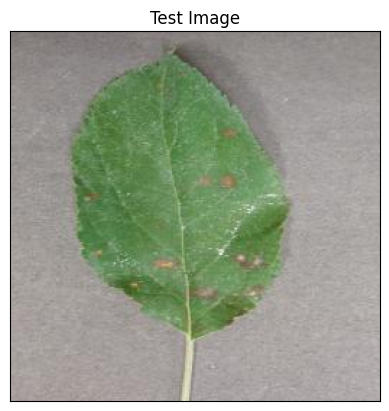

In [25]:
import cv2
import matplotlib.pyplot as plt
import os

# Corrected image path
image_path = r"C:\Users\vnekn\OneDrive\Documents\DataSetPPT\New Plant Diseases Dataset(Augmented)\train\Apple___Cedar_apple_rust\0a41c25a-f9a6-4c34-8e5c-7f89a6ac4c40___FREC_C.Rust 9807.JPG"

# Verify if the file exists
if not os.path.exists(image_path):
    raise FileNotFoundError(f"File not found: {image_path}")

# Reading the image
img = cv2.imread(image_path)

# Check if the image was successfully loaded
if img is None:
    raise ValueError(f"Unable to read the image at {image_path}")

# Converting BGR to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Displaying the image
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks
plt.show()


## Testing Model

In [26]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
predictions = cnn.predict(input_arr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step


In [27]:
print(predictions)

[[1.4377690e-11 1.6993794e-09 1.0000000e+00 7.5540797e-14 3.7960503e-12
  1.2343734e-12 9.8740062e-15 3.6426379e-10 3.8617611e-16 1.7494934e-11
  1.6193303e-17 2.6794018e-12 1.2846141e-14 4.0783660e-16 8.1513555e-12
  2.0313009e-13 2.3857039e-10 4.4338930e-13 3.6327540e-12 1.6075779e-13
  1.9707722e-14 1.0997621e-13 1.1478614e-13 1.3834413e-14 1.4532172e-14
  5.0400737e-14 3.2557943e-13 1.2958303e-15 4.4619042e-10 7.0817909e-12
  3.1727521e-09 1.2654797e-14 4.2875236e-08 1.5447943e-15 4.9665561e-10
  1.3133482e-14 8.4874341e-14 6.9770396e-12]]


In [28]:
result_index = np.argmax(predictions) #Return index of max element
print(result_index)

2


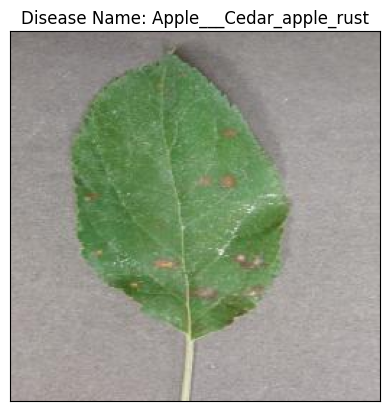

In [29]:
# Displaying the disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()